# Course Project: Implement a Neural Network for Sentiment Analysis

In [2]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
import time


In this course project, you will implement a neural network that performs sentiment analysis for a binary classification problem. You will:

1. Load the book review data set.
2. Create training and test datasets.
3. Transform the training and test text data using a TF-IDF vectorizer. 
4. Construct a neural network
5. Train the neural network.
6. Compare the model's performance on the training data vs test data.
7. Improve its generalization performance.

For this project, you may use the previous demos you were shown in this course as reference: <i>Transforming Text into Features for Sentiment Analysis</i> and <i>Implementing a Neural Network in Keras</i>. 

**<font color='red'>Note: some of the code cells in this notebook may take a while to run</font>**

## Part 1:  Load the Data Set

We will work with the book review data set that contains book reviews taken from Amazon.com reviews.

<b>Task</b>: In the code cell below, use the same method you have been using to load the data using `pd.read_csv()` and save it to DataFrame `df`.

You will be working with the file named "bookReviews.csv" that is located in a folder named "data".

In [3]:
# YOUR CODE HERE
## Cell 01 -- done ran wo error looks correct next cell
## Goal 01.01 df = pd.read_csv(bookReviews.csv in data)
filename = os.path.join(os.getcwd(), "data", "bookReviews.csv")
df = pd.read_csv(filename, header=0)

In [3]:
df.head()

,Review,Positive Review
0,This was perhaps the best of Johannes Steinhof...,True
1,This very fascinating book is a story written ...,True
2,The four tales in this collection are beautifu...,True
3,The book contained more profanity than I expec...,False
4,We have now entered a second time of deep conc...,True


In [5]:
df.shape

## out:  (1973, 2)

(1973, 2)

## Part 2: Create Training and Test Data Sets

### Create Labeled Examples

<b>Task</b>: Create labeled examples from DataFrame `df`. 
In the code cell below carry out the following steps:

* Get the `Positive Review` column from DataFrame `df` and assign it to the variable `y`. This will be our label.
* Get the `Review` column from  DataFrame `df` and assign it to the variable `X`. This will be our feature. 


In [6]:
# YOUR CODE HERE
## Cell 02 -- done, runs looks corect next cell
## Goal 02.01: y = "Positive Review", x = "Review"
## Code source notes, similar to coding lab in this course "TransformingTextUsingWordEmbeddings"

y = df['Positive Review']
X = df['Review']


In [8]:
X.head()

0    This was perhaps the best of Johannes Steinhof...
1    This very fascinating book is a story written ...
2    The four tales in this collection are beautifu...
3    The book contained more profanity than I expec...
4    We have now entered a second time of deep conc...
Name: Review, dtype: object

In [9]:
X.shape 
## out (1973,)   makes sense, just the one column

(1973,)

### Split Labeled Examples into Training and Test Sets


<b>Task</b>: In the code cell below, create training and test sets out of the labeled examples. 

1. Use scikit-learn's `train_test_split()` function to create the data sets.

2. Specify:
    * A test set that is 20 percent of the size of the data set.
    * A seed value of '1234'. 
    

In [10]:
# YOUR CODE HERE
## Cell 03 -- done -- runs wo error, next also runs confirms
## Goal 03.01: scikit-learn's train_test_split() function w/ test set = .20 (=.80 for train), seed = 1234

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.80,random_state=1234)

In [11]:
X_train.head()

1369    As my brother said when flipping through this ...
1366    Cooper's book is yet another warm and fuzzy ma...
385     I have many robot books and this is the best a...
750     As China re-emerges as a dominant power in the...
643     I have been a huge fan of Michael Crichton for...
Name: Review, dtype: object

## Part 3:  Implement TF-IDF Vectorizer to Transform Text


In the code cell below, you will transform the features into numerical vectors using `TfidfVectorizer`. 


<b>Task:</b> Follow the steps to complete the code in the cell below:

1. Create a `TfidfVectorizer` object and save it to the variable `tfidf_vectorizer`.

2. Call `tfidf_vectorizer.fit()` to fit the vectorizer to the training data `X_train`.

3. Call the `tfidf_vectorizer.transform()` method to use the fitted vectorizer to transform the training data `X_train`. Save the result to `X_train_tfidf`.

4. Call the `tfidf_vectorizer.transform()` method to use the fitted vectorizer to transform the test data `X_test`. Save the result to `X_test_tfidf`.

In [12]:
# 1. Create a TfidfVectorizer object 
# YOUR CODE HERE
## Cell 04.01 -- done - ran without error all of cell 04 and following cell ran to confirm. 
## Goal: tfidf_vectorizer = TfidfVectorizer() ?
## code source notes: mentioned in video M2 04 "Using Word Embeddings"... it's a "good weight to use" or something like that
## https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
tfidf_vectorizer = TfidfVectorizer()


# 2. Fit the vectorizer to X_train
# YOUR CODE HERE
## Cell 04.02 -- done
## Goal: tfidf_vectorizer.fit() w X_train   ...not x = v.fit() ?
tfidf_vectorizer.fit(X_train)


# 3. Using the fitted vectorizer, transform the training data 
# YOUR CODE HERE
## Cell 04.03 -- done
## Goal: X_train_tfidf = tfidf_vectorizer.transform() w X_train ...ah current scikit docu shows fit and transform combined

X_train_tfidf = tfidf_vectorizer.transform(X_train)

# 4. Using the fitted vectorizer, transform the test data 
# YOUR CODE HERE
## Cell 04.04 -- done
## Goal: X_test_tfidf = tfidf_vectorizer.transform() w X_test
X_test_tfidf = tfidf_vectorizer.transform(X_test)


When constructing our neural network, we will have to specify the `input_shape`, meaning the dimensionality of the input layer. This corresponds to the dimension of each of the training examples, which in our case is our vocabulary size. Run the code cell below to see the vocabulary size.


In [13]:
vocabulary_size = len(tfidf_vectorizer.vocabulary_)

print(vocabulary_size)

## output 19029

19029


## Part 4: Construct a Neural Network


### Step 1.  Define Model Structure

Next we will create our neural network structure. We will create an input layer, three hidden layers and an output layer:

* <b>Input layer</b>: The input layer will have the input shape corresponding to the vocabulary size. 
* <b>Hidden layers</b>: We will create three hidden layers of widths (number of nodes) 64, 32, and 16. They will utilize the ReLu activation function. 
* <b>Output layer</b>: The output layer will have a width of 1. The output layer will utilize the sigmoid activation function. Since we are working with binary classification, we will be using the sigmoid activation function to map the output to a probability between 0.0 and 1.0. We can later set a threshold and assume that the prediction is class 1 if the probability is larger than or equal to our threshold, or class 0 if it is lower than our threshold.

To construct the neural network model using Keras, we will do the following:
* We will use the Keras `Sequential` class to group a stack of layers. This will be our neural network model object.
* We will use the `InputLayer` class to create the input layer. 
* We will use the `Dense` class to create every hidden layer and the output layer. 
* We will add each layer to the neural network model object.

<b>Task:</b> Follow these steps to complete the code in the cell below:

1. Create the neural network model object. 
    * Use ``keras.Sequential() `` to create a model object, and assign the result to the variable ```nn_model```.
    
    
2. Create the input layer: 
    * Call `keras.layers.InputLayer()` with the argument `input_shape=(vocabulary_size,)` to specify the dimension of the input.
    * Assign the results to the variable `input_layer`.
    * Use `nn_model.add(input_layer)` to add the layer `input_layer` to the neural network model object.


3. Create the first hidden layer:
    * Call `keras.layers.Dense()` with the arguments `units=64` and `activation='relu'`. 
    * Assign the results to the variable `hidden_layer_1`.
    * Use `nn_model.add(hidden_layer_1)` to add the layer `hidden_layer_1` to the neural network model object.


4. Create the second hidden layer using the same approach that you used to create the first hidden layer, specifying 32 units and the `relu` activation function. 
    * Assign the results to the variable `hidden_layer_2`.
    * Add the layer to the neural network model object.
    
    
5. Create the third hidden layer using the same approach that you used to create the first two hidden layers, specifying 16 units and the `relu` activation function. 
    * Assign the results to the variable `hidden_layer_3`.
    * Add the layer to the neural network model object.


6. Create the output layer using the same approach that you used to create the hidden layers, specifying 1 unit and the `signmoid` activation function. 
   * Assign the results to the variable `output_layer`.
   * Add the layer to the neural network model object.
   

In [14]:
# 1. Create model object
# YOUR CODE HERE
## Cell 05.01 -- done
## Goal: Use keras.Sequential() to create a model object, and assign the result to the variable nn_model
## Goal2: nn_model = keras.Sequential()
## code source notes similar to previous lab "Neural Network Demo"

nn_model = keras.Sequential()



# 2. Create the input layer and add it to the model object: 

# Create input layer:
input_layer = keras.layers.InputLayer(input_shape=(vocabulary_size,)) 
## Cell 05.02 (above) -- drafted
## Goal 05.02.01: Call keras.layers.InputLayer() with the argument input_shape=(vocabulary_size,) to specify 
##                the dimension of the input.
##                Assign the results to the variable input_layer.


# Add input_layer to the model object:
# YOUR CODE HERE
## Cell 05.03 -- done
## Goal 05.03.01: Use nn_model.add(input_layer) to add the layer input_layer to the neural network model object.
nn_model.add(input_layer)


# 3. Create the first hidden layer and add it to the model object:

# Create input layer:
hidden_layer_1 = keras.layers.Dense(units=64,activation='relu')
## Cell 05.04 (ABOVE) -- done
## Goal 05.04.01: Call keras.layers.Dense() with the arguments units=64 and activation='relu'.
##                Assign the results to the variable hidden_layer_1.

# Add hidden_layer_1 to the model object:
# YOUR CODE HERE
## Cell 05.05 -- done
## Goal 05.05.01: Use nn_model.add(hidden_layer_1) to add the layer hidden_layer_1 to the neural network model object.
nn_model.add(hidden_layer_1)
nn_model.add(keras.layers.Dropout(.20))


# 4. Create the second layer and add it to the model object:

# Create input layer:
hidden_layer_2 = keras.layers.Dense(units=32,activation='relu')
## Cell 05.06 (above) -- done
## Goal 05.06.01: Create the second hidden layer using the same approach that you used to create the first hidden layer, 
##                 specifying 32 units and the relu activation function.
##                Assign the results to the variable hidden_layer_2.


# Add hidden_layer_2 to the model object:
# YOUR CODE HERE
## Cell 05.07 -- done
## Goal 05.07.01: Add the layer to the neural network model object. [See above code that you build out, copy and modify]
nn_model.add(hidden_layer_2)
nn_model.add(keras.layers.Dropout(.20))

# 5. Create the third layer and add it to the model object:

# Create input layer:
hidden_layer_3 = keras.layers.Dense(units=16,activation='relu')
## Cell 05.08 (above) -- done
## Goal 05.08.01: Create the third hidden layer using the same approach that you used to create the first two hidden layers, 
##                 specifying 16 units and the relu activation function.
##               Assign the results to the variable hidden_layer_3.

# Add hidden_layer_3 to the model object:
# YOUR CODE HERE
## Cell 05.09 -- done
## Goal 05.09.01: Add the layer to the neural network model object. zzz use code built above
nn_model.add(hidden_layer_3)


## Final Task Goals: Add Keras Dropout layers after one or all hidden layers. 
##                   Add the following line of code after you add a hidden layer to 
##                   your model object: nn_model.add(keras.layers.Dropout(.25)). 
##                   The parameter .25 is the fraction of the nodes to drop. 
##                   You can experiment with this value as well. Restart and rerun all of the cells above. 
##                   Evaluate the performance of the model on the training data and the test data.
## useful code source documetation: https://keras.io/api/layers/regularization_layers/dropout/
## it's going to "trim" the data, sounds like epoch tuning might work differently after I add this

nn_model.add(keras.layers.Dropout(.20))  ## it ran, looks correct based on documentation on code also

## Round 5: 0.25, Round 6 0.25 (reduced epochs to 40), 
## Round 7 increase to 0.30 ... more trimming I think...
## Round 8 decrease to 20... worse perf after 30
## Round 9 try adding dropout to all hidden layers, and at 0.1 less trimming
## Round 10 still overfitting, increase trim to 0.25 (reset) and reduce epochs to 25

# 6. Create the output layer and add it to the model object:

# Create input layer: ## I think this should say "output layer"
output_layer = keras.layers.Dense(units=1, activation='sigmoid', name='output')
## Cell 05.10 (above) -- done
## Goal 05.10.01: Create the output layer using the same approach that you used to create the hidden layers, 
##               specifying 1 unit and the signmoid activation function.
##                Assign the results to the variable output_layer.
## example in lab has final variable included name='output' but it's not specified here. Left in for first draft


# Add output_layer to the model object:
# YOUR CODE HERE
## Cell 05.11 -- done
## Goal: Add the layer to the neural network model object. zzz see code and docs above, define document more
nn_model.add(output_layer)


# Print summary of neural network model structure
nn_model.summary()

#Output: (table)


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                1217920   
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dropout_1 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_2 (Dense)              (None, 16)                528       
_________________________________________________________________
dropout_2 (Dropout)          (None, 16)                0         
_________________________________________________________________
output (Dense)               (None, 1)                 1

### Step 2. Define the Optimization Function

<b>Task:</b> In the code cell below, create a stochastic gradient descent optimizer using  `keras.optimizers.SGD()`. Specify a learning rate of 0.1 using the `learning_rate` parameter. Assign the result to the variable`sgd_optimizer`.

In [15]:
# YOUR CODE HERE
## Cell 06 -- done
## Goal 06.01 
sgd_optimizer=keras.optimizers.SGD(learning_rate=0.1)

### Step 3. Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. Assign the result to the variable  `loss_fn`.

In [16]:
# YOUR CODE HERE
## Cell 07 -- done
## Goal 07.01: loss_fn =  keras.losses.BinaryCrossentropy(from_logits=False)
loss_fn =  keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4. Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. 


You will specify the optimizer, loss function and accuracy evaluation metric. Call the `nn_model.compile()` method with the following arguments:
* Use the `optimizer` parameter and assign it your optimizer variable:`optimizer=sgd_optimizer`
* Use the `loss` parameter and assign it your loss function variable: `loss=loss_fn`
* Use the `metrics` parameter and assign it the `accuracy` evaluation metric: `metrics=['accuracy']`
   

In [17]:
# YOUR CODE HERE
## Cell 08 -- done
## Goal: nn_model.compile(optimizer=sgd_optimizer,loss=loss_fn,metrics=['accuracy'])
nn_model.compile(optimizer=sgd_optimizer,loss=loss_fn,metrics=['accuracy'])

## Part 5. Fit the Model on the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [18]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> In the code cell below, fit the neural network model to the vectorized training data.

1. Call `nn_model.fit()` with the training data `X_train_tfidf` and `y_train` as arguments. Note that `X_train_tfidf` is currently of type sparse matrix. The Keras `fit()` method requires that input data be of specific types. One type that is allowed is a NumPy array. Convert `X_train_tfidf` to a NumPy array using the `toarray()` method.


2. In addition, specify the following parameters:

    * Use the `epochs` parameter and assign it the variable to `epochs`: `epochs=num_epochs`
    * Use the `verbose` parameter and assign it the value of  0: `verbose=0`
    * Use the `callbacks` parameter and assign it a list containing our logger function: 
    `callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)]`  
    * We will use a portion of our training data to serve as validation data. Use the  `validation_split` parameter and assign it the value `0.2`
    
    
    
3. Save the results to the variable `history`. 

<b>Note</b>: This may take a while to run.

In [19]:

t0 = time.time() # start time

num_epochs = 2 #epochs
## For final experimental step
## Goal: Tweak the variable num_epochs above and restart and rerun all of the cells. 
##       Evaluate the performance of the model on the training data and the test data.

## prep array
X_train_tfidf_array=X_train_tfidf.toarray()

history = nn_model.fit(
    X_train_tfidf_array,
    y_train,
    epochs=num_epochs,
    verbose=0,
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=1)],
    validation_split=0.2
    )
## ## Cell 09 (above) done
## Goal 09.01: [history = ] nn_model.fit(
##             X_train_tfidf_array,y_train,epochs: epochs=num_epochs,verbose=0,
##             callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=1)],  ## changed from 5
##             We will use a portion of our training data to serve as validation data. 
##             Use the validation_split parameter and assign it the value 0.2
##             )
## Goal 09.02: sub / prep: X_train_tfidf_array=toarray(X_train_tfidf)
## code process notes: did I get the valication_split param? added now round 2 done



t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

## Output  (NOT FINAL, before adding validation split param)

## Epoch [5/ 50], Loss: 0.6854, Accuracy: 0.5646
## Epoch [10/ 50], Loss: 0.5842, Accuracy: 0.7104
## Epoch [15/ 50], Loss: 0.4255, Accuracy: 0.7959
## Epoch [20/ 50], Loss: 0.3241, Accuracy: 0.8676
## Epoch [25/ 50], Loss: 0.0599, Accuracy: 0.9924
## Epoch [30/ 50], Loss: 0.0114, Accuracy: 1.0000
## Epoch [35/ 50], Loss: 0.0038, Accuracy: 1.0000
## Epoch [40/ 50], Loss: 0.0021, Accuracy: 1.0000
## Epoch [45/ 50], Loss: 0.0014, Accuracy: 1.0000
## Epoch [50/ 50], Loss: 0.0010, Accuracy: 1.0000
## Elapsed time: 29.43s


## Output done

## Epoch [5/ 50], Loss: 0.0008, Accuracy: 1.0000, Val_loss: 0.0009, Val_accuracy: 1.0000
## Epoch [10/ 50], Loss: 0.0006, Accuracy: 1.0000, Val_loss: 0.0008, Val_accuracy: 1.0000
## Epoch [15/ 50], Loss: 0.0006, Accuracy: 1.0000, Val_loss: 0.0007, Val_accuracy: 1.0000
## Epoch [20/ 50], Loss: 0.0005, Accuracy: 1.0000, Val_loss: 0.0006, Val_accuracy: 1.0000
## Epoch [25/ 50], Loss: 0.0004, Accuracy: 1.0000, Val_loss: 0.0006, Val_accuracy: 1.0000
## Epoch [30/ 50], Loss: 0.0004, Accuracy: 1.0000, Val_loss: 0.0006, Val_accuracy: 1.0000
## Epoch [35/ 50], Loss: 0.0003, Accuracy: 1.0000, Val_loss: 0.0005, Val_accuracy: 1.0000
## Epoch [40/ 50], Loss: 0.0003, Accuracy: 1.0000, Val_loss: 0.0005, Val_accuracy: 1.0000
## Epoch [45/ 50], Loss: 0.0003, Accuracy: 1.0000, Val_loss: 0.0005, Val_accuracy: 1.0000
## Epoch [50/ 50], Loss: 0.0003, Accuracy: 1.0000, Val_loss: 0.0004, Val_accuracy: 1.0000
## Elapsed time: 45.64s

## output -- epoch = 30
## Epoch [5/ 30], Loss: 0.0002, Accuracy: 1.0000, Val_loss: 0.0004, Val_accuracy: 1.0000
## Epoch [10/ 30], Loss: 0.0002, Accuracy: 1.0000, Val_loss: 0.0004, Val_accuracy: 1.0000
## Epoch [15/ 30], Loss: 0.0002, Accuracy: 1.0000, Val_loss: 0.0004, Val_accuracy: 1.0000
## Epoch [20/ 30], Loss: 0.0002, Accuracy: 1.0000, Val_loss: 0.0004, Val_accuracy: 1.0000
## Epoch [25/ 30], Loss: 0.0002, Accuracy: 1.0000, Val_loss: 0.0004, Val_accuracy: 1.0000
## Epoch [30/ 30], Loss: 0.0002, Accuracy: 1.0000, Val_loss: 0.0003, Val_accuracy: 1.0000
## Elapsed time: 18.20s

## output, epoch = 15
## Epoch [5/ 15], Loss: 0.0002, Accuracy: 1.0000, Val_loss: 0.0003, Val_accuracy: 1.0000
## Epoch [10/ 15], Loss: 0.0002, Accuracy: 1.0000, Val_loss: 0.0003, Val_accuracy: 1.0000
## Epoch [15/ 15], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0003, Val_accuracy: 1.0000
## Elapsed time: 14.79s

## Output epoch =5 , round 3
## Epoch [5/ 5], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0003, Val_accuracy: 1.0000
## Elapsed time: 3.17s

## Output, epoch = 75, round 4
## Epoch [5/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0003, Val_accuracy: 1.0000
## Epoch [10/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0003, Val_accuracy: 1.0000
## Epoch [15/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0003, Val_accuracy: 1.0000
## Epoch [20/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0003, Val_accuracy: 1.0000
## Epoch [25/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0003, Val_accuracy: 1.0000
##Epoch [30/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0003, Val_accuracy: 1.0000
## Epoch [35/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0003, Val_accuracy: 1.0000
## Epoch [40/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0003, Val_accuracy: 1.0000
## Epoch [45/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0003, Val_accuracy: 1.0000
## Epoch [50/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0002, Val_accuracy: 1.0000
## Epoch [55/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0002, Val_accuracy: 1.0000
## Epoch [60/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0002, Val_accuracy: 1.0000
## Epoch [65/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0002, Val_accuracy: 1.0000
## Epoch [70/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0002, Val_accuracy: 1.0000
## Epoch [75/ 75], Loss: 0.0001, Accuracy: 1.0000, Val_loss: 0.0002, Val_accuracy: 1.0000
## Elapsed time: 20.36s


## Output Round 5 (Keras Dropout = 0.25)

## Epoch [5/ 50], Loss: 0.6885, Accuracy: 0.5769, Val_loss: 0.6885, Val_accuracy: 0.5095
## Epoch [10/ 50], Loss: 0.6308, Accuracy: 0.7155, Val_loss: 0.6661, Val_accuracy: 0.5222
## Epoch [15/ 50], Loss: 0.5321, Accuracy: 0.7425, Val_loss: 0.6412, Val_accuracy: 0.6044
## Epoch [20/ 50], Loss: 0.4167, Accuracy: 0.8043, Val_loss: 0.6302, Val_accuracy: 0.6867
## Epoch [25/ 50], Loss: 0.1583, Accuracy: 0.9596, Val_loss: 0.5161, Val_accuracy: 0.7722
## Epoch [30/ 50], Loss: 0.0313, Accuracy: 0.9984, Val_loss: 0.4763, Val_accuracy: 0.8165
## Epoch [35/ 50], Loss: 0.0113, Accuracy: 0.9992, Val_loss: 0.5610, Val_accuracy: 0.7975
## Epoch [40/ 50], Loss: 0.0068, Accuracy: 1.0000, Val_loss: 0.5756, Val_accuracy: 0.8070
## Epoch [45/ 50], Loss: 0.0047, Accuracy: 1.0000, Val_loss: 0.6139, Val_accuracy: 0.7975
## Epoch [50/ 50], Loss: 0.0041, Accuracy: 0.9992, Val_loss: 0.6461, Val_accuracy: 0.8006
## Elapsed time: 14.67s

## Output Round 6 (epochs down to 40)

## Epoch [5/ 40], Loss: 0.0045, Accuracy: 1.0000, Val_loss: 0.6681, Val_accuracy: 0.8070
## Epoch [10/ 40], Loss: 0.0030, Accuracy: 0.9992, Val_loss: 0.6945, Val_accuracy: 0.8006
## Epoch [15/ 40], Loss: 0.0022, Accuracy: 1.0000, Val_loss: 0.7127, Val_accuracy: 0.8070
## Epoch [20/ 40], Loss: 0.0017, Accuracy: 1.0000, Val_loss: 0.7287, Val_accuracy: 0.8006
## Epoch [25/ 40], Loss: 0.0028, Accuracy: 1.0000, Val_loss: 0.7456, Val_accuracy: 0.8070
## Epoch [30/ 40], Loss: 0.0039, Accuracy: 0.9984, Val_loss: 0.7662, Val_accuracy: 0.8070
## Epoch [35/ 40], Loss: 0.0026, Accuracy: 1.0000, Val_loss: 0.7830, Val_accuracy: 0.8070
## Epoch [40/ 40], Loss: 0.0008, Accuracy: 1.0000, Val_loss: 0.7945, Val_accuracy: 0.8070
## Elapsed time: 12.09s

Epoch [1/ 2], Loss: 0.6933, Accuracy: 0.5166, Val_loss: 0.6944, Val_accuracy: 0.4905
Epoch [2/ 2], Loss: 0.6930, Accuracy: 0.5000, Val_loss: 0.6929, Val_accuracy: 0.4905
Elapsed time: 3.14s


### Visualize the Model's Performance Over Time

The code above outputs both the training loss and accuracy and the validation loss and accuracy. Let us visualize the model's performance over time:

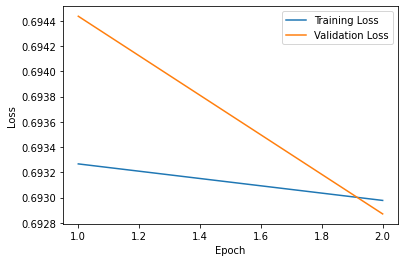

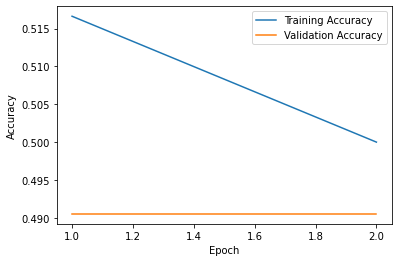

In [20]:
# Plot training and validation loss
plt.plot(range(1, num_epochs + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs + 1), history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Plot training and validation accuracy
plt.plot(range(1, num_epochs + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## errors: KeyError 'val_loss'   STOPPED HERE 2/26/2026 9:20am  still errors.. see above section...split validation?
## ah yes corrected code 'history' above and error is not here now, fixed/resolved. Cont'd here 2/27/2026

## Part 6. Improve the Model and Evaluate the Performance

We just evaluated our model's performance on the training and validation data. Let's now evaluate its performance on our test data and compare the results.

Keras makes the process of evaluating our model very easy. Recall that when we compiled the model we specified the metric we wanted to use to evaluate the model: accuracy. The Keras method `evaluate()` will return the loss and accuracy score of our model on our test data.

<b>Task:</b> In the code cell below, call `nn_model.evaluate()` with `X_test_tfidf` and `y_test` as arguments. You must convert `X_test_tfidf` to a NumPy array using the `toarray()` method. 

Note: The `evaluate()` method returns a list containing two values. The first value is the loss and the second value is the accuracy score.


In [21]:
## prep array
X_test_tfidf_array=X_test_tfidf.toarray()

loss, accuracy =  nn_model.evaluate(X_test_tfidf_array,y_test)
## Cell 10 (above) -- done, matches results in text cell below
## Goal 10.01: prep --  X_test_tfidf_array=toarray(X_test_tfidf) -- similiar to process above code, now test vs train above
## Goal 10.02: nn_model.evaluate(X_test_tfidf_array,y_test)


print('Loss: ', str(loss) , 'Accuracy: ', str(accuracy))

## Output
## 13/13 [==============================] - 0s 11ms/step - loss: 0.5989 - accuracy: 0.8278
## Loss:  0.5988513231277466 Accuracy:  0.8278480768203735

## Output Round 1

## 13/13 [==============================] - 0s 11ms/step - loss: 0.6223 - accuracy: 0.8253
## Loss:  0.6223487854003906 Accuracy:  0.8253164291381836

## Output Round 2
## 13/13 [==============================] - 0s 13ms/step - loss: 0.6307 - accuracy: 0.8253
## Loss:  0.6307281851768494 Accuracy:  0.8253164291381836

## Output Round 3
## 13/13 [==============================] - 0s 3ms/step - loss: 0.6325 - accuracy: 0.8253
## Loss:  0.6325238347053528 Accuracy:  0.8253164291381836


## output Round 4
## 13/13 [==============================] - 0s 3ms/step - loss: 0.6632 - accuracy: 0.8253
## Loss:  0.6631740927696228 Accuracy:  0.8253164291381836

## Output roun 5 ... in spreadsheet zzz

## Output round 6 
## 13/13 [==============================] - 0s 2ms/step - loss: 0.7965 - accuracy: 0.8253
## Loss:  0.796457827091217 Accuracy:  0.8253164291381836

## Output Round 7

## 13/13 [==============================] - 0s 3ms/step - loss: 0.5907 - accuracy: 0.7899
## Loss:  0.5906875729560852 Accuracy:  0.7898734211921692

13/13 [==============================] - 0s 4ms/step - loss: 0.6925 - accuracy: 0.5038
Loss:  0.6924965381622314 Accuracy:  0.5037974715232849


### Prevent Overfitting and Improve Model's Performance

Neural networks can be prone to overfitting. Notice that the training accuracy is 100% but the test accuracy is around 82%. This indicates that our model is overfitting; it will not perform as well on new, previously unseen data as it did during training. We want to have an accurate idea of how well our model will generalize. Our goal is to have our training and testing accuracy scores be as close as possible.

While there are different techniques that can be used to prevent overfitting, for the purpose of this exercise we will focus on two methods:

1. Changing the number of epochs. Too many epochs can lead to overfitting of the training dataset, whereas too few epochs may result in underfitting.

2. Adding dropout regularization. During training, the nodes of a particular layer may always become influenced only by the output of a particular node in the previous layer, causing overfitting. Dropout regularization is a technique that randomly drops a number of nodes in a neural network during training as a way of adding randomization and preventing nodes from becoming dependent on one another. Adding dropout regularization can reduce overfitting and also improve the performance of the model. 

<b>Task:</b> 

1. Tweak the variable `num_epochs` above and restart and rerun all of the cells above. Evaluate the performance of the model on the training data and the test data.

2. Add Keras `Dropout` layers after one or all hidden layers. Add the following line of code after you add a hidden layer to your model object:  `nn_model.add(keras.layers.Dropout(.25))`. The parameter `.25` is the fraction of the nodes to drop. You can experiment with this value as well. Restart and rerun all of the cells above. Evaluate the performance of the model on the training data and the test data.


<b>Analysis:</b> 
In the cell below, specify the different approaches you used to reduce overfitting and summarize which configuration led to the best generalization performance.

Did changing the number of epochs prevent overfitting? Which value of `num_epochs` yielded the closest training and testing accuracy score? Recall that too few epochs can lead to underfitting (both poor training and test performance). Which value of `num_epochs` resulted in the best accuracy score when evaluating the test data?

Did adding dropout layers prevent overfitting? How so? Did it also improve the accuracy score when evaluating the test data? How many dropout layers did you add and which fraction of nodes did you drop? 

Record your findings in the cell below.

Cell 11 -- drafting
Goal/Plan: Record experimental methods (variables changed w each run), and results. Capture in excel separately I guess?

Task 1: vary the value of "epochs" and run the model, recording results. Goal: want to Training and Test Accuracy to be similar in value otherwise the model is overfit. Looking at results of Baseline model, where epochs are 50, the model is overfit. The Basemodel Test Accuracy was 82.78% but the Training Accuracy (how well I though that the model would do) was 100%.

Overfitting can be corrected in a model by decreasing the epochs, so I re-ran the model, modifying the epoch and capturing the Test and Training Accuracy and Loss. I decreased the epochs from 50 to 40 to 30 to 15 to 5, then up to 75 to see if the model was sensitive to larger increases in epochs.

Here are my results as a data table. 
		Input	Outcomes	Outcomes	Outcomes	Outcomes	Interpretation	NextRoundAdvice
What	TimeSeries	epochs	Training_Accuracy	Training_Loss	Test_Accuracy	Test_Loss		
Baseline	0	50	100%	0.0003	82.78%	60%	Overfitting	reduce epochs
Round 1	1	30	100%	0.0002	82.53%	62%	Overfitting	reduce epochs more?
Round 2	2	15	100%	0.0001	82.53%	63%	Overfitting	reduce epochs more?
Round 3	3	5	100%	0.0001	82.53%	63%	Overfitting	increase epochs, any worse?
Round 4	4	75	100%	0.0001	82.53%	66%	Overfitting	seems insensitive to epoch changes
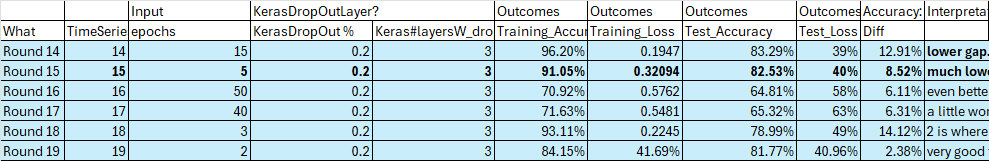


The model did not seem very sensitive to chnages in epoch changes. I could explore this more but I think there may be other parameters to optimize that may make number of epochs have a larger impact so I think I will move on to the next parameter which is incoporating Keras dropout as an addition to the hidden layers in the model. This process randomly "trims" a percent of the data, randomly selected, for that hidden layer. Once I built in the dropout components I added them to each hidden layer, and along with the epoch value, I was able to have a better fitting model, with the difference between the Training Accuracy and the Test Accuracy reduced to 2%. I have described my methods and results more in the following sections that match this written assignment's requirments.



__Specify the different approaches you used to reduce overfitting and summarize which configuration led to the best generalization performance.

__Did changing the number of epochs prevent overfitting? Which value of num_epochs yielded the closest training and testing accuracy score? Recall that too few epochs can lead to underfitting (both poor training and test performance). Which value of num_epochs resulted in the best accuracy score when evaluating the test data?

__Did adding dropout layers prevent overfitting? How so? Did it also improve the accuracy score when evaluating the test data? How many dropout layers did you add and which fraction of nodes did you drop?

Context and Goals (again):

The Neural Network model was overfit to the training data, as evident by the disparity between the Training and Test accuracy scores.

First thing I tried to reduce overfitting was to reduce the number of epochs in the model but this had little impact on the accuracy scores disparties. (Round 1 to Round 4, above).

Next I added a dropout component to the model for just the 3rd hidden layer (Round 5 to Round 8) where I observed model performance (accuracy) as I varied epochs some, mostly varied dropout percent on the 1 hidden layer. This also had little impact on reducing the overfit of the model, the gap between the accuracy of the test and of the training remained between 16% and 21%. See table below
What	TimeSeries	epochs	KerasDropOut %	Keras#layersW_dropout	Training_Accuracy	Training_Loss	Test_Accuracy	Test_Loss	Diff	
Round 5	5	50	0.25	1	99.92%	0.0041	83.04%	65%	16.88%	Graph for validation over time is all over the place then settles over time…diff slightly reduced, maybe trim up to 30? First redeuce epochs see if any effect…in results table I think it shows nothing trimmed…
Round 6	6	40	0.25	1	100.00%	0.0008	82.53%	80%	17.47%	a bit worse behavior….overfitting more….could increase dropout rate in hidden layer… then try adding dropout to all hidden layers at 0.25
Round 7	7	50	0.30	1	99.60%	0.0531	78.99%	59%	20.61%	graph v spikey wow, worse performance…try reducing from 0.25
Round 8	8	50	0.2	1	100.00%	0.0107	82.28%	62%	17.72%	0.1 on all hidden layers next
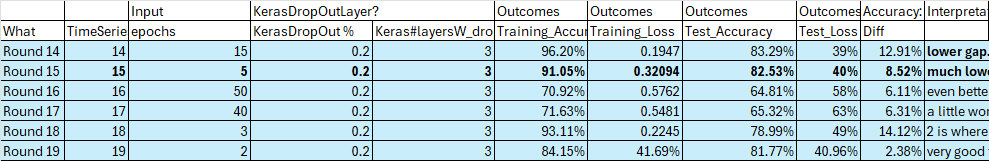

After that I added the same dropout components to each of the three hidden layers of the model, tried to vary the epoch and dropout rate to experiement and optimize the parameters that way, for Round 9 to Round 13. But this is not a linear process so in many cases it was worse at meeting the goal of low difference between the test and training accuracy. ith the worse gaps for example in at 20 epochs with dropout rate 0.25 in Round 11, where training accuracy = 99.68%, and test was a terrible 52.17%, having a difference of 47.51%, showing big overfit. 

I started looking at the graphs/charts more after Round 13, and realized that if I wanted to optimize Accuracy (High) and Loss (Low) in the training that would translate to better fit of test, I could compare the two charts and see where there are interections between accuracy and loss, where also loss was low and accuracy was high. I do feel like there's probably a better computational way to do this but it's good to see how it works kind of poking around and I made it to the graphs eventually. I would like to take the time to add more minor tick marks and a grid but I'll save that for another day.

For Round 14 and beyond I decreased the epochs from 30 to 15 then to 5 in Round 15 to really zoom in and try a more extreme (5 is much lower than original 50) epochs parameter varing. Got my best result so far in terms of fitting, with a gap of only 13%, with 5 epochs and each hidden layer w dropout at 20%. So it was a good indication that my interpretation of the graphs to optimize the neural net parameters was logical. I "zoomed out" on the graphs in the next Round (16) to 50 epochs to see if I could see any more or better patterns at that level, and my gap improved to 6.11%. Looking at the chart, I could see several interesting intersections of optimization to explore, 1 just below 40 epochs. Round 17 explored this spot, but the performance wasn't much better from Round 15. I could see from the chart that there was another intersection around epoch 3, so I tried that next for Round 18. Could see quickly from the chart that epoch 2 had the lowest intersection point I was trying for, which I did in Round 19. 

For Round 19 I used 2 epochs, with all 3 hidden layers in the model having dropout rates of 20%. This model showed good model performance (good model fit) between the test and training accuracy, with  84.15% for Training vs. 81.77% for Test, a difference of  2.38%. Respectively, the Training loss was 41.69% and the Test loss was 40.96%.

		Input	KerasDropOutLayer?		Outcomes	Outcomes	Outcomes	Outcomes	Accuracy: Train vs Test	Interpretation
What	TimeSeries	epochs	KerasDropOut %	Keras#layersW_dropout	Training_Accuracy	Training_Loss	Test_Accuracy	Test_Loss	Diff	
Round 14	14	15	0.2	3	96.20%	0.1947	83.29%	39%	12.91%	lower gap…I think I need to look at the graphs more…the intersections might inform parameters. Decrease to epoch 5 or increase to 100 for graph
Round 15	15	5	0.2	3	91.05%	0.32094	82.53%	40%	8.52%	much lower gap, the intersection are where it's at… NEW BASELINE / best result. Can I do better? Incraese epochs look for more intersection…this is so manual…
Round 16	16	50	0.2	3	70.92%	0.5762	64.81%	58%	6.11%	even better gap… looking at graph I want lowest loss …just below 40 epochs shows intersection in both loss and accuracy tables between training and validation...a good optimizing sign...decrease epoch 40
Round 17	17	40	0.2	3	71.63%	0.5481	65.32%	63%	6.31%	a little worse… but wanted to see chart and look for other intersection to try…a big one (maybe?) at like epoch 3?
Round 18	18	3	0.2	3	93.11%	0.2245	78.99%	49%	14.12%	2 is where I was after not 3 can see from charts, do 2
Round 19	19	2	0.2	3	84.15%	41.69%	81.77%	40.96%	2.38%	very good fit, NEW BEST
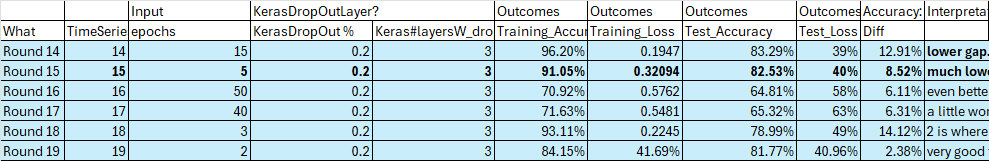

### Make Predictions on the Test Set

Now that we have our best performing model that can generalize to new, previously unseen data, let us make predictions using our test data.

In the cell below, we will make a prediction on our test set using the `predict()` method, receive a probability between 0.0 and 1.0, and then apply a threshold to obtain the the predicted class for each example. We will use a threshold of 0.5.

For the first 10 examples, we will output their probabilities and the corresponding classes. Examine the output to see how this works.

In [22]:
probability_predictions = nn_model.predict(X_test_tfidf.toarray())

print("Predictions for the first 10 examples:")
print("Probability\t\t\tClass")
for i in range(0,10):
    if probability_predictions[i] >= .5:
        class_pred = "Good Review"
    else:
        class_pred = "Bad Review"
    print(str(probability_predictions[i]) + "\t\t\t" + str(class_pred))

Predictions for the first 10 examples:
Probability			Class
[0.50499016]			Good Review
[0.50601834]			Good Review
[0.50310695]			Good Review
[0.50387967]			Good Review
[0.50577503]			Good Review
[0.5065167]			Good Review
[0.5065507]			Good Review
[0.5049622]			Good Review
[0.50756675]			Good Review
[0.5058088]			Good Review


Let's check two book reviews and see if our model properly predicted whether the reviews are good or bad reviews.

In [23]:
print('Review #1:\n')
print(X_test.to_numpy()[56])

goodReview = True if probability_predictions[56] >= .5 else False
    
print('\nPrediction: Is this a good review? {}\n'.format(goodReview))

print('Actual: Is this a good review? {}\n'.format(y_test.to_numpy()[56]))

Review #1:

This commentary has many tremendous insights into the book of Romans.  Romans is one of the richest resources of truth within the Bible and John Stoot does a good job of unpacking it.  The book is written from a framework of the reader having a strong prior understanding of the Scriptures.  It is probably not considered a highly scholarly work, but it is not for the average reader to pick up for light reading either


Prediction: Is this a good review? True

Actual: Is this a good review? True



In [24]:
print('Review #2:\n')
print(X_test.to_numpy()[24])

goodReview = True if probability_predictions[24] >= .5 else False

print('\nPrediction: Is this a good review? {}\n'.format(goodReview)) 

print('Actual: Is this a good review? {}\n'.format(y_test.to_numpy()[24]))

Review #2:

I have read Baldacci's first four novels and have immensely enjoyed all of them.  This one, however, is just awful.  Not only the character's dialogue but even the story itself is written like a really bad detective movie.  The only thing I can think of to compare it to is this :  There was a series of Calvin and Hobbes cartoons where Calvin imagines himself as a private detective and they are written like the old detective shows, with lame lines like "The gun was loaded, and so was I".  That is exactly what this book is like, except it goes on for 400 pages.  There isn't a single interesting character in this book, in my opinion.  You just have to slog your way through the book to get to the end.  It's the Bataan Death March of novels.  I hope this is an aberration - I'll certainly give him another try since the first four novels that I read were so good.  But one more stinker like this one and I'll drop his name from my reading list


Prediction: Is this a good review? Tr

### Deep Dive (Ungraded):

Experiment with the vectorizer and neural network implementation above and compare your results every time you train the network. Pay attention to the time it takes to train the network, and the resulting loss and accuracy on both the training and test data. 

Below are some ideas for things you can try:

* Adjust the learning rate.
* Add more hidden layers and/or experiment with different values for the `unit` parameter in the hidden layers to change the number of nodes in the hidden layers.
* Fit your vectorizer using different document frequency values and different n-gram ranges. When creating a `TfidfVectorizer` object, use the parameter `min_df` to specify the minimum 'document frequency' and use `ngram_range=(1,2)` to change the default n-gram range of `(1,1)`.
